In [1]:
from google.colab import files
import pandas as pd

uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

Saving final_labeled_dataset.csv to final_labeled_dataset.csv


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df.dropna(subset=['headline', 'sentiment'], inplace=True)
label_encoder = LabelEncoder()
df['sentiment_encoded'] = label_encoder.fit_transform(df['sentiment'])


print("Sentiment Label Mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label}: {i}")

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X = tfidf_vectorizer.fit_transform(df['headline'])
y = df['sentiment_encoded']

Sentiment Label Mapping:
negative: 0
neutral: 1
positive: 2


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 2008 samples
Testing set size: 503 samples


Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best parameters for Multinomial Naive Bayes: {'alpha': 0.5}
Best cross-validation score for Multinomial Naive Bayes: 0.7096728614029999

--- Multinomial Naive Bayes Results ---
Accuracy: 0.7037773359840954
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.86      0.76       228
           1       0.71      0.20      0.31        86
           2       0.72      0.75      0.74       189

    accuracy                           0.70       503
   macro avg       0.71      0.60      0.60       503
weighted avg       0.71      0.70      0.68       503



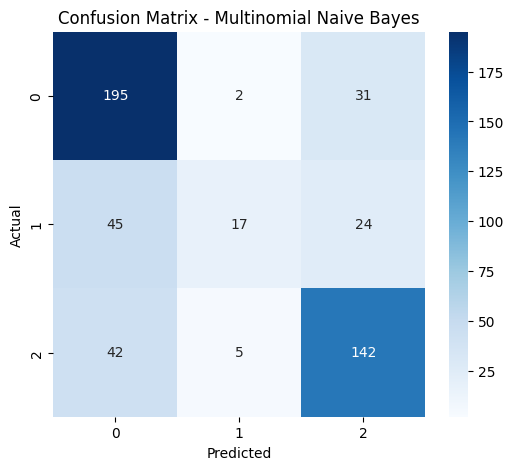

In [9]:
from sklearn.naive_bayes import MultinomialNB

nb_params = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]
}

nb_grid = GridSearchCV(
    MultinomialNB(),
    nb_params,
    cv=3,
    verbose=1,
    n_jobs=-1
)

nb_grid.fit(X_train, y_train)

print("Best parameters for Multinomial Naive Bayes:", nb_grid.best_params_)
print("Best cross-validation score for Multinomial Naive Bayes:", nb_grid.best_score_)

best_nb = nb_grid.best_estimator_

y_pred_nb = best_nb.predict(X_test)

print("\n--- Multinomial Naive Bayes Results ---")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Classification Report:\n", classification_report(y_test, y_pred_nb))

cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Multinomial Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [10]:
df['predicted_sentiment_naive_bayes'] = label_encoder.inverse_transform(
    best_nb.predict(X)
)

display(df[['headline', 'sentiment', 'predicted_sentiment_naive_bayes']].head())

,headline,sentiment,predicted_sentiment_naive_bayes
0,KBL returns to court over alleged corruption i...,negative,negative
1,India's Gen Z protesters adapt to internet shu...,negative,negative
2,"Who is Karim Khan, the barrister at the center...",negative,negative
3,Body found dumped along Nairobi–Naivasha Highw...,negative,negative
4,"Two including Italian killed, two injured in R...",negative,negative


In [11]:
output_file = "naive_bayes_predicted_sentiments.csv"

df.to_csv(output_file, index=False)

print(f"Output file saved as: {output_file}")

Output file saved as: naive_bayes_predicted_sentiments.csv


In [17]:
from sklearn.metrics import f1_score

y_pred_nb = best_nb.predict(X_test)

f1_nb = f1_score(y_test, y_pred_nb, average='macro')

print("Naive Bayes Macro F1 Score:", round(f1_nb, 3))

Naive Bayes Macro F1 Score: 0.603


In [12]:
from google.colab import files

files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>